## Proyeco de Regresion lineal de Predecir el coste del seguro medico de una persona.

- Importamos las librerias necesarias para este ejercicio

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


- Paso 1: Cargamos el Dataset con el que vamos a trabajar

In [2]:
# Cargar datos
url = 'https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv'

df = pd.read_csv(url)

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.shape

(1338, 7)

- Paso 2: Analizamos el Dataset y hacemos el EDA

In [7]:
# Revisamos valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

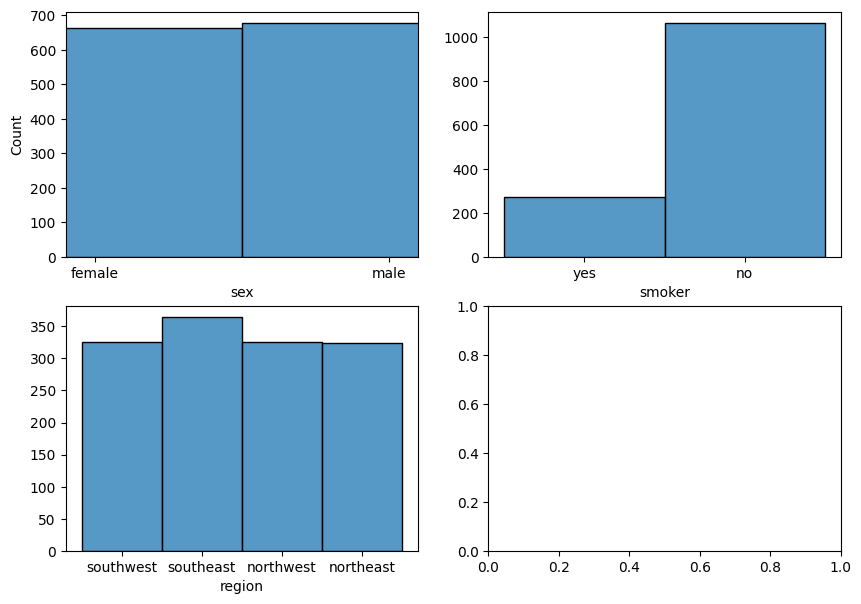

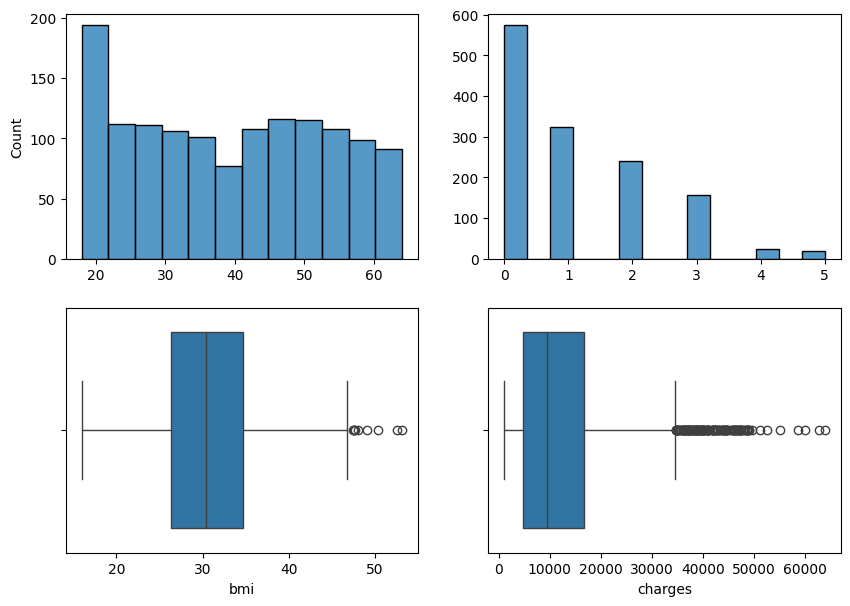

In [8]:
# Variables categóricas

fig, axis = plt.subplots(2, 2, figsize = (10, 7))
# Gráficos para variables categóricas

sns.histplot(ax = axis[0, 0], data = df, x = "sex").set_xlim(-0.1, 1.1)
sns.histplot(ax = axis[0 ,1], data = df, x = "smoker").set(ylabel = None)
sns.histplot(ax = axis[1, 0], data = df, x = "region").set(ylabel = None)

# Ajustar el layout
plt.tight_layout

# Mostrar el plot
plt.show()

# Variables numericas
fig, axis = plt.subplots(2, 2, figsize = (10,7))

# Graficos de variables numericas
sns.histplot(ax = axis[0, 0], data = df, x = "age").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "bmi")
sns.histplot(ax = axis[0, 1], data = df, x = "children").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "charges")

# Ajustar el layout
plt.tight_layout

# Mostrar el plot
plt.show()

- Nos fijamos que las variables "charges" y "bmi" tienen valores atipicos

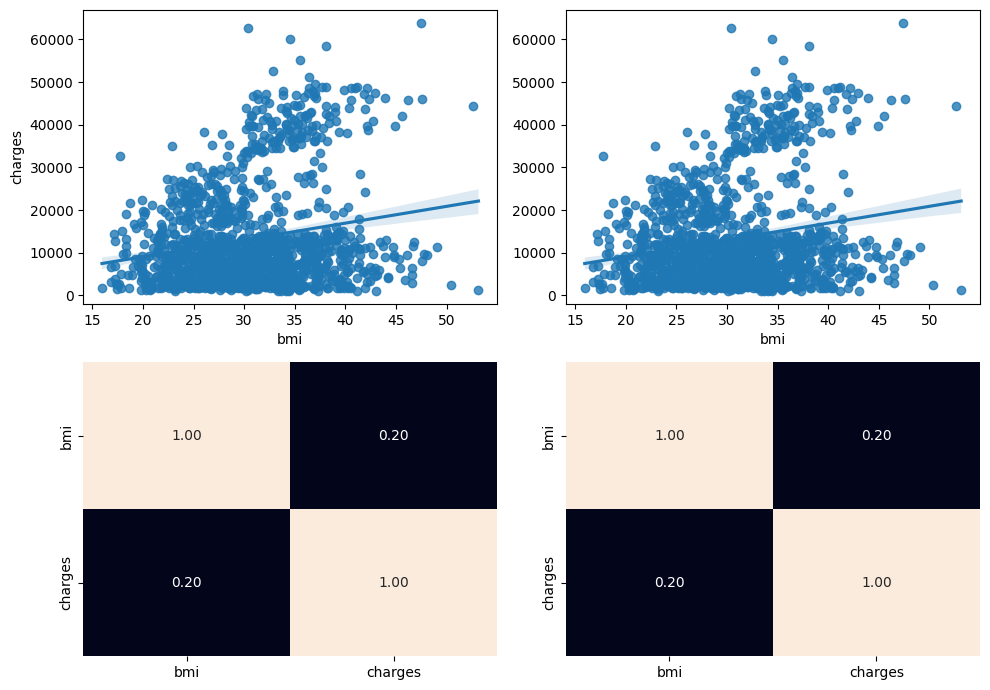

In [9]:
# Analisis numerico-numerico
fig, axis = plt.subplots(2, 2, figsize = (10, 7))

# Creamos un diagrama de dispersion
sns.regplot(ax = axis[0, 0], data = df, x = "bmi", y = "charges")
sns.heatmap(df[["bmi", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = df, x = "bmi", y = "charges").set(ylabel = None)
sns.heatmap(df[["bmi", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

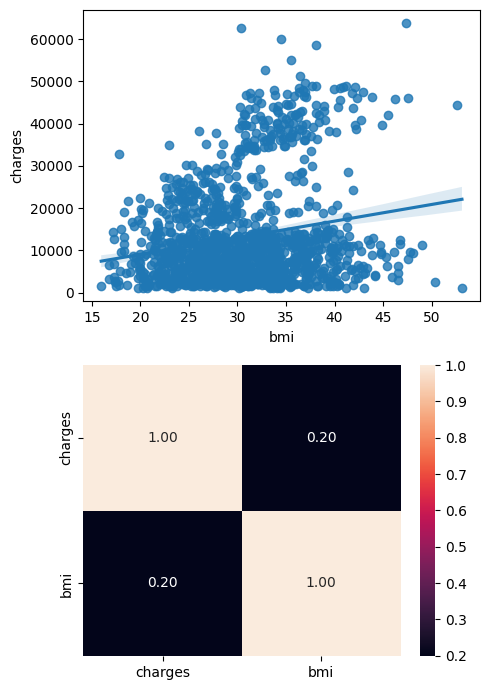

In [ ]:
#  Correlacionamos ambas variables
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0], data = df, x = "bmi", y = "charges")
sns.heatmap(df[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()


## analisis
- con este analis podemos decir que la pirma del seguro crece esponencialmente pero no esta relacionada con el indice de masa coprporal(bmi).

In [11]:
# Mapear variables categóricas a números
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['region'] = df['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})


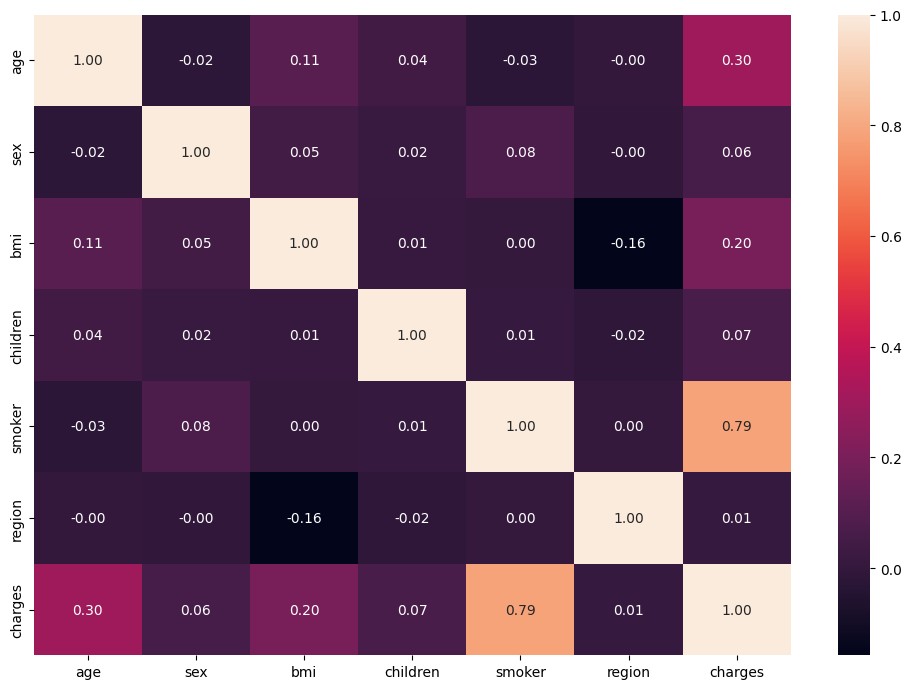

In [12]:
# Analisis categorico numerico
fig, axis = plt.subplots(figsize = (10, 7))

sns.heatmap(df[["age", "sex", "bmi", "children", "smoker", "region", "charges"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

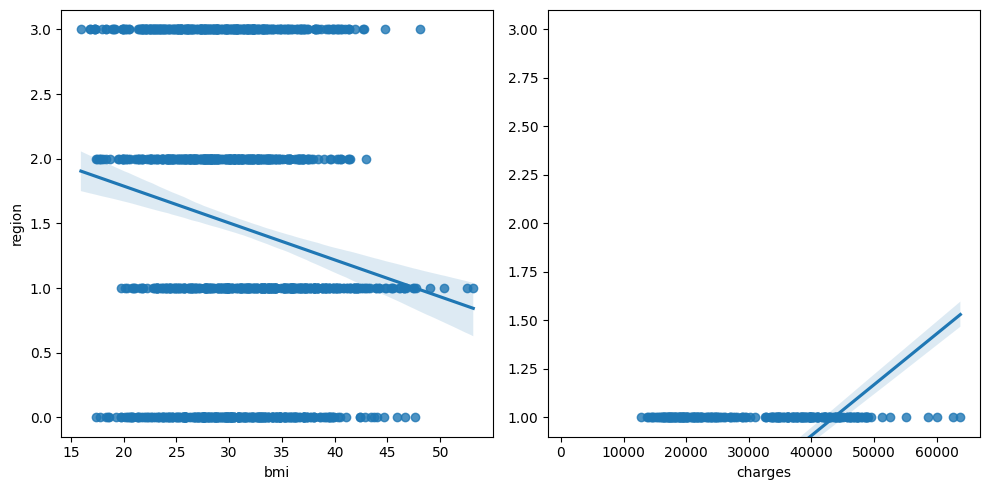

In [ ]:
dffig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.regplot(ax = axis[0], data = df, x = "charges", y = "smoker")
sns.regplot(ax = axis[1], data = df, x = "bmi", y = "region").set(ylabel = None, ylim = (0.9, 3.1))

plt.tight_layout()

plt.show()


## Analisis:
- En el primer grafico vemos como el indice de fumadores aumenta con la prima pues los fumadores pueden tener mas riesgo de enfermedades
- y en el segundo vemos como la region esta relacionada neativamente con el indice de masa corporal.

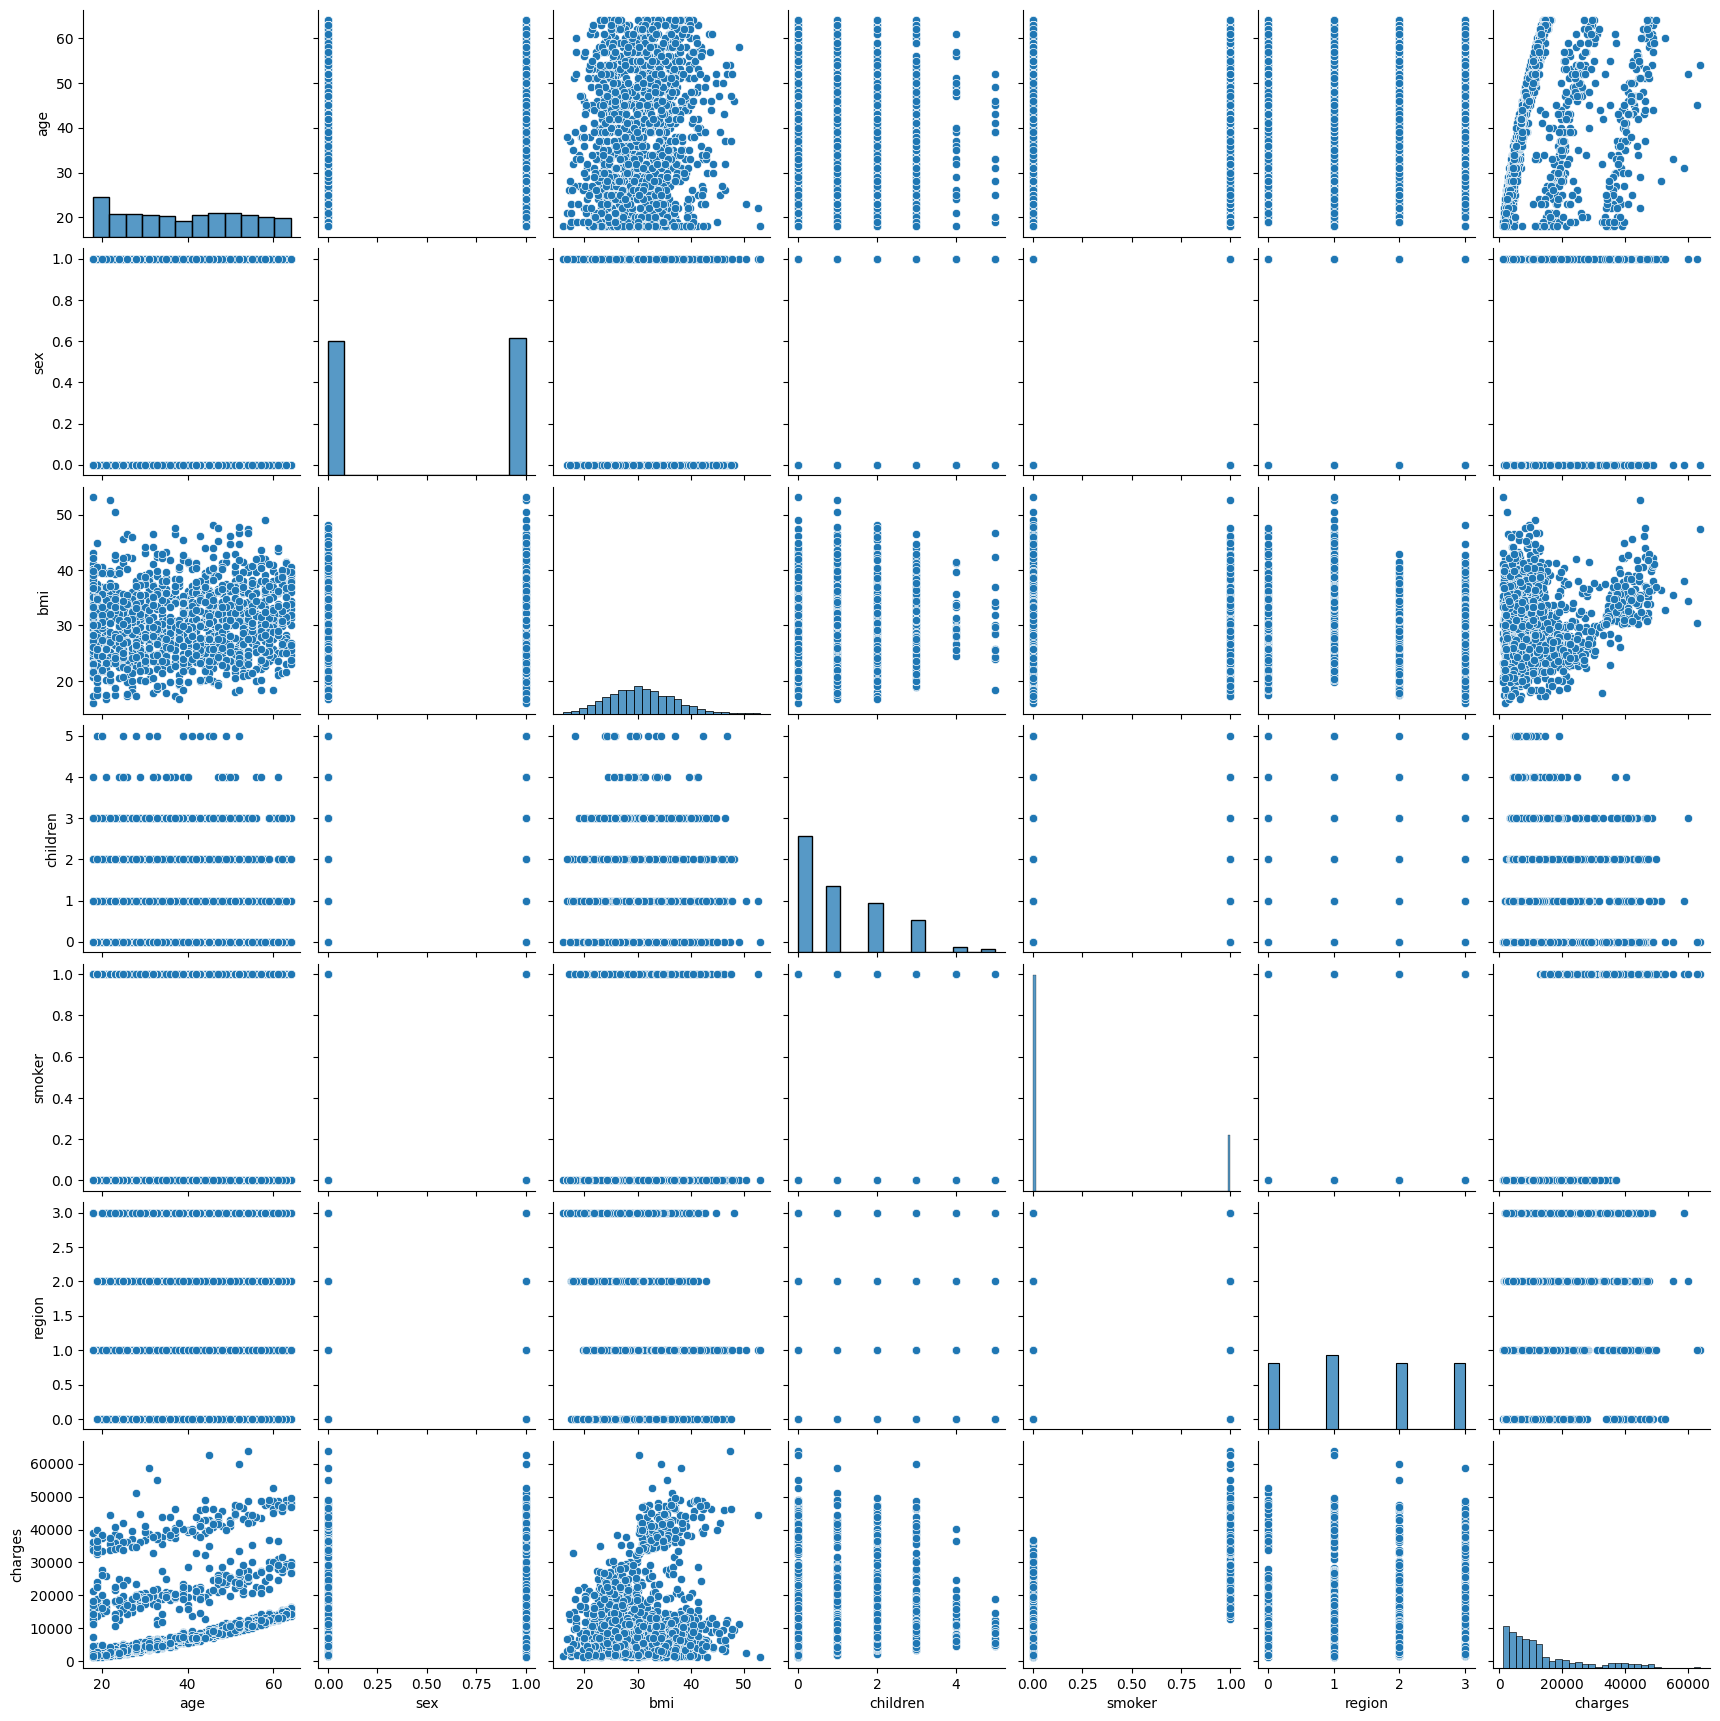

In [14]:
sns.pairplot(data = df)

- Ingenieria de caracteristicas
- Analisis de outliers

In [15]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.484305,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,1.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


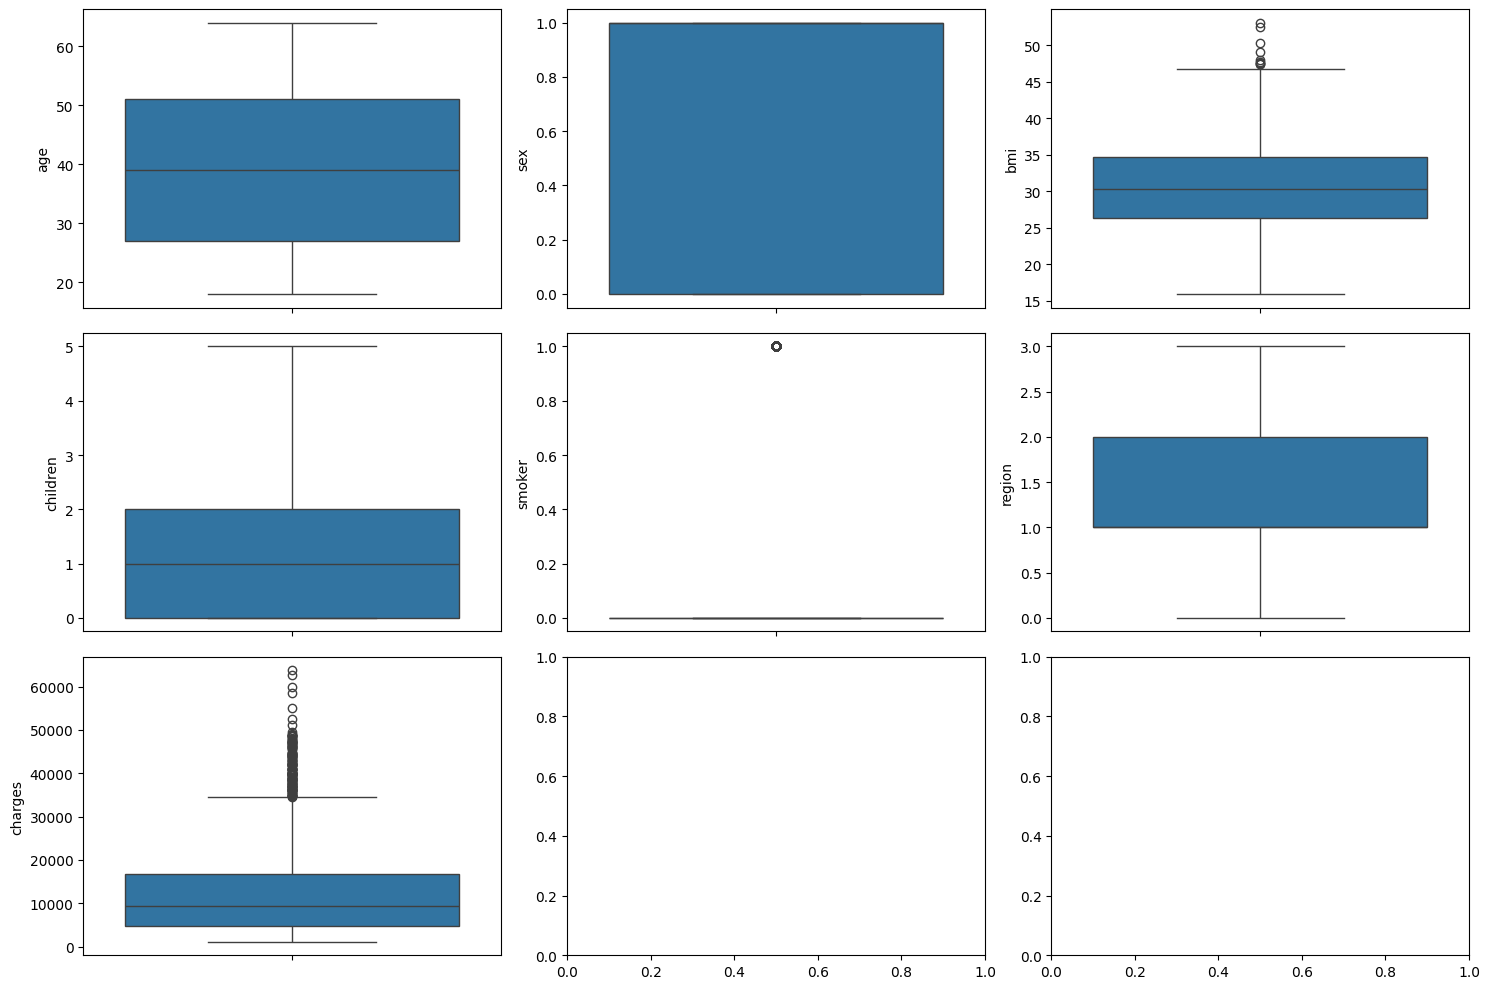

In [ ]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = df, y = "age")
sns.boxplot(ax = axis[0, 1], data = df, y = "sex")
sns.boxplot(ax = axis[0, 2], data = df, y = "bmi")
sns.boxplot(ax = axis[1, 0], data = df, y = "children")
sns.boxplot(ax = axis[1, 1], data = df, y = "smoker")
sns.boxplot(ax = axis[1, 2], data = df, y = "region")
sns.boxplot(ax = axis[2, 0], data = df, y = "charges")

plt.tight_layout()

plt.show()

In [17]:
charges_stats = df["charges"].describe()
charges_stats

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [18]:
charges_iqr = charges_stats["75%"] - charges_stats["25%"]
upper_limit = charges_stats["75%"] + 1.5 * charges_iqr
lower_limit = charges_stats["25%"] - 1.5 * charges_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(charges_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 34489.35 y -13109.15, con un rango intercuartílico de 11899.63


In [20]:
df[df["charges"] > 30000]

,age,sex,bmi,children,smoker,region,charges
14,27,1,42.130,0,1,1,39611.75770
19,30,1,35.300,0,1,0,36837.46700
23,34,0,31.920,1,1,3,37701.87680
29,31,1,36.300,2,1,0,38711.00000
30,22,1,35.600,0,1,0,35585.57600
...,...,...,...,...,...,...,...
1301,62,1,30.875,3,1,2,46718.16325
1303,43,1,27.800,0,1,0,37829.72420
1308,25,0,30.200,0,1,0,33900.65300
1313,19,0,34.700,2,1,0,36397.57600


- En este caso exite mucha 